In [ ]:
#import packages and define functions for calculations


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cartopy.feature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import glob
import os
import warnings
warnings.filterwarnings('ignore')


from mpl_toolkits.axes_grid1 import make_axes_locatable
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.ticker import AutoMinorLocator


import regionmask


import warnings
warnings.filterwarnings("ignore")

Figure1: A line graph showing the differences of surface temperature mean between Global scenario and East Asia

In [ ]:
#surface air temperatures (tas)
#tas historical
filename_tas_historical_1='Data/tas_Amon_UKESM1-0-LL_historical_r1i1p1f2_gn_185001-194912.nc'
filename_tas_historical_2='Data/tas_Amon_UKESM1-0-LL_historical_r1i1p1f2_gn_195001-201412.nc'
#tas ssp370
filename_tas_ssp370_1='data/UKESM1_model_output/ssp370/tas_Amon_UKESM1-0-LL_ssp370_r1i1p1f2_gn_201501-204912.nc'
filename_tas_ssp370_2='data/UKESM1_model_output/ssp370/tas_Amon_UKESM1-0-LL_ssp370_r1i1p1f2_gn_205001-210012.nc'
#combine tas historical
tas_historical=xr.open_mfdataset(paths=[filename_tas_historical_1,filename_tas_historical_2],combine='by_coords')
tas_hist=tas_historical.tas
#combine tas ssp370
tas_ssp370=xr.open_mfdataset(paths=[filename_tas_ssp370_1,filename_tas_ssp370_2],combine='by_coords')
tas_370=tas_ssp370.tas

In [ ]:
#Set as anomalies, baseline 1981-2010
tas_hist_annual = tas_hist.groupby('time.year').mean()
tas_370_annual  = tas_370.groupby('time.year').mean()

baseline = tas_hist_annual.sel(year=slice(1981, 2010)).mean('year')

tasA_hist = tas_hist_annual - baseline
tasA_370  = tas_370_annual  - baseline

In [ ]:
# create some area-weights to average the fields with
weights=tas_hist[0,:,:]
weights = np.cos(np.deg2rad(tas_historical.lat))
weights.name = "weights"

#Make some field with the weighting applied
tasA_wgtd_hist=tasA_hist.weighted(weights)
tasA_wgtd_370=tasA_370.weighted(weights)


In [ ]:
#Create the global mean temperatures...
gmt_hist = tasA_wgtd_hist.mean(dim=('lat', 'lon'))
gmt_370= tasA_wgtd_370.mean(dim=('lat', 'lon'))

In [ ]:
#Create some 5 year smoothed versions (60 months)
gmt_hist=gmt_hist.chunk(1980)
gmt_hist_smoothed=gmt_hist.rolling(time=60,center=True).mean(dim=('time'))
gmt_370=gmt_370.chunk(1032)
gmt_370_smoothed=gmt_370.rolling(time=60,center=True).mean(dim=('time'))

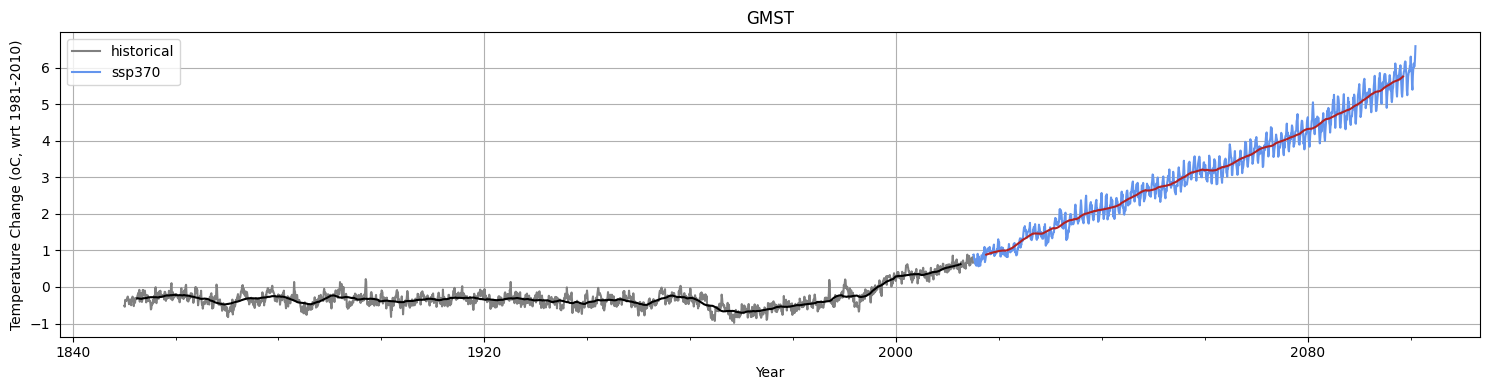

In [ ]:
# Create a line plot of monthly global mean surface temperature anomalies
#After looking at the differences in surface temperature, what is the rationale behind
#in this study we will look at the variable psl and precipitation
fig, ax = plt.subplots(figsize=(15,4))
gmt_hist.plot(ax=ax, label='historical',color='grey')
gmt_370.plot(ax=ax, label='ssp370',color='cornflowerblue')
gmt_hist_smoothed.plot(ax=ax,color='black')
gmt_370_smoothed.plot(ax=ax,color='firebrick')
ax.grid()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc='best')
ax.set(xlabel='Year',ylabel='Temperature Change (oC, wrt 1981-2010)')
ax.set_title('GMST')

plt.tight_layout()
plt.show()

East Asian Region

<regionmask.Regions 'AR6 reference regions'>
Source:   Iturbide et al., 2020 (ESSD)
overlap:  False

Regions:
 0 GIC      Greenland/Iceland
 1 NWN      N.W.North-America
 2 NEN      N.E.North-America
 3 WNA        W.North-America
 4 CNA        C.North-America
..  ..                    ...
53 ARS            Arabian-Sea
54 BOB          Bay-of-Bengal
55 EIO Equatorial.Indic-Ocean
56 SIO          S.Indic-Ocean
57 SOO         Southern-Ocean

[58 regions]

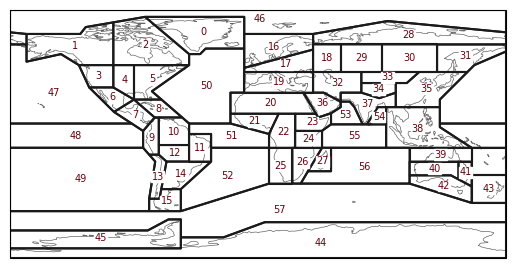

In [ ]:
# Show what regions are available
regionmask.defined_regions.ar6.all.plot(text_kws=dict(color="#67000d", fontsize=7, bbox=dict(pad=0.2, color="w")))
regionmask.defined_regions.ar6.all

In [ ]:
for region in regionmask.defined_regions.ar6.all:
    print(region.number, region.abbrev, region.name)

0 GIC Greenland/Iceland
1 NWN N.W.North-America
2 NEN N.E.North-America
3 WNA W.North-America
4 CNA C.North-America
5 ENA E.North-America
6 NCA N.Central-America
7 SCA S.Central-America
8 CAR Caribbean
9 NWS N.W.South-America
10 NSA N.South-America
11 NES N.E.South-America
12 SAM South-American-Monsoon
13 SWS S.W.South-America
14 SES S.E.South-America
15 SSA S.South-America
16 NEU N.Europe
17 WCE West&Central-Europe
18 EEU E.Europe
19 MED Mediterranean
20 SAH Sahara
21 WAF Western-Africa
22 CAF Central-Africa
23 NEAF N.Eastern-Africa
24 SEAF S.Eastern-Africa
25 WSAF W.Southern-Africa
26 ESAF E.Southern-Africa
27 MDG Madagascar
28 RAR Russian-Arctic
29 WSB W.Siberia
30 ESB E.Siberia
31 RFE Russian-Far-East
32 WCA W.C.Asia
33 ECA E.C.Asia
34 TIB Tibetan-Plateau
35 EAS E.Asia
36 ARP Arabian-Peninsula
37 SAS S.Asia
38 SEA S.E.Asia
39 NAU N.Australia
40 CAU C.Australia
41 EAU E.Australia
42 SAU S.Australia
43 NZ New-Zealand
44 EAN E.Antarctica
45 WAN W.Antarctica
46 ARO Arctic-Ocean
47 NPO 

In [ ]:
# Select East Asia region (EAS = 37)
east_asia = regionmask.defined_regions.ar6.all[[35]]

<GeoAxes: >

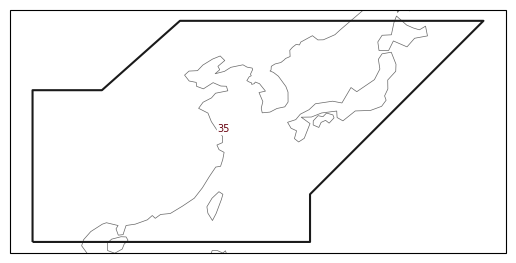

In [ ]:
east_asia.plot(
    text_kws=dict(color="#67000d", fontsize=7, bbox=dict(pad=0.2, color="w"))
)

In [ ]:
# First of all, annual average of all the temperature data loaded above
ann_tasA_hist = tasA_hist.groupby("time.year").mean()
ann_tasA_370 = tasA_370.groupby("time.year").mean()


In [ ]:
# Then we create a mask and apply it over East Asia (region number 35)
mask = regionmask.defined_regions.ar6.all.mask(ann_tasA_hist)
EAS_weights=weights.where(mask == 35 ,0) # The ,0 in the where commands sets the weight as 0 outside region 35.

In [ ]:
# Now we take the weighted average over the regional to create a timeseries
EAS_hist=ann_tasA_hist.weighted(EAS_weights).mean(dim=('lat', 'lon'))
EAS_370=ann_tasA_370.weighted(EAS_weights).mean(dim=('lat', 'lon'))

In [ ]:
# Use min_periods=1 and smaller window to handle short arrays
EAS_hist_smoothed = EAS_hist.rolling(year=5, center=True, min_periods=1).mean()
EAS_370_smoothed  = EAS_370.rolling( year=5, center=True, min_periods=1).mean()

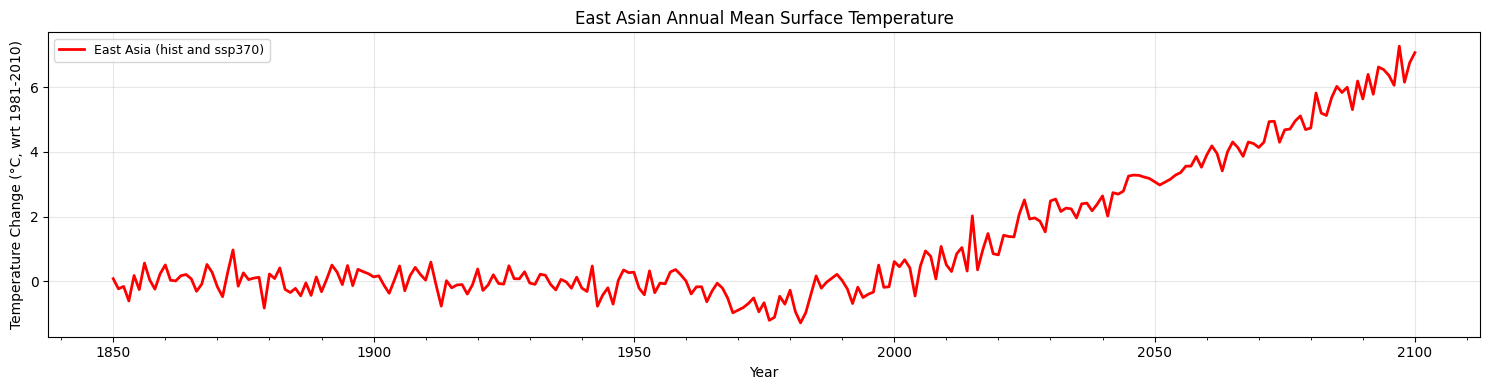

In [ ]:
# Create a line plot of annual mean surface temperature anomalies over East Asian
#East Asia
all_years = np.concatenate([EAS_hist.year.values, EAS_370.year.values])
all_values = np.concatenate([EAS_hist.values, EAS_370.values])


fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(all_years, all_values, color='grey', lw=0.8, alpha=0.4)
ax.plot(all_years, all_values, color='red', lw=2, label='East Asia (hist and ssp370)')

ax.grid(True, alpha=0.3)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc='upper left', fontsize=9)
ax.set(xlabel='Year', ylabel='Temperature Change (°C, wrt 1981-2010)')
ax.set_title('East Asian Annual Mean Surface Temperature')

plt.tight_layout()
plt.show()

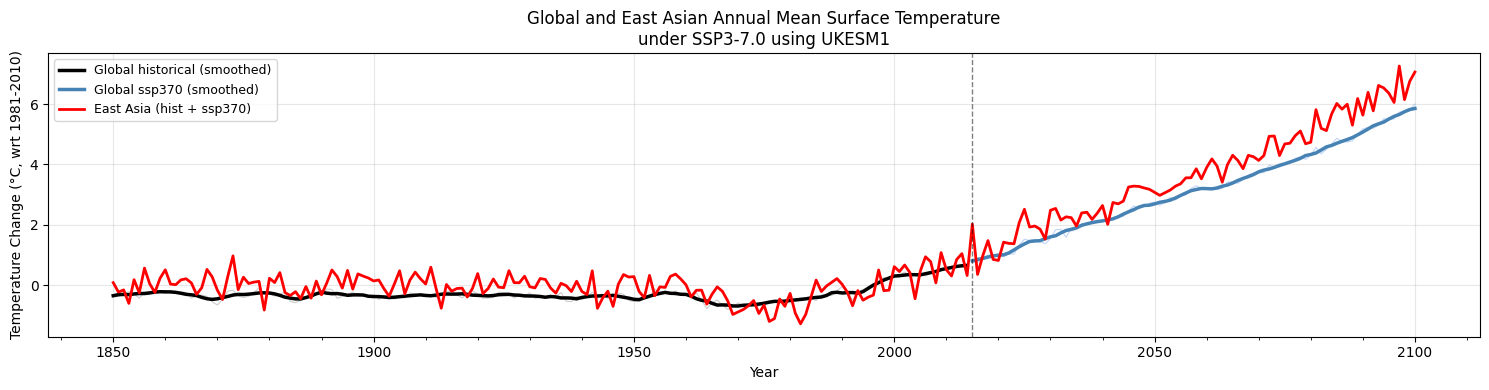

In [ ]:
#Combined plot:
# GMT monthly data converted into annually
gmt_hist_annual          = gmt_hist.resample(time='YS').mean()
gmt_370_annual           = gmt_370.resample(time='YS').mean()
gmt_hist_smoothed_annual = gmt_hist.rolling(
    time=60, center=True, min_periods=1).mean().resample(time='YS').mean()
gmt_370_smoothed_annual = gmt_370.rolling(
    time=60, center=True, min_periods=1).mean().resample(time='YS').mean()

# Extract years from each dataset
gmt_years = gmt_hist_annual.time.dt.year.values
gmt_370_years = gmt_370_annual.time.dt.year.values
eas_hist_years = EAS_hist.year.values
eas_370_years  = EAS_370.year.values

fig, ax = plt.subplots(figsize=(15, 4))

# Global tas plotting (blue)
ax.plot(gmt_years, gmt_hist_annual.values,
        color='grey', lw=0.8, alpha=0.4)
ax.plot(gmt_years, gmt_hist_smoothed_annual.values,
        color='black', lw=2.5, label='Global historical (smoothed)')


ax.plot(gmt_370_years, gmt_370_annual.values,
        color='cornflowerblue', lw=0.8, alpha=0.4)
ax.plot(gmt_370_years, gmt_370_smoothed_annual.values,
        color='steelblue', lw=2.5, label='Global ssp370 (smoothed)')

# East Asia tas plotting (Red)
ax.plot(eas_hist_years, EAS_hist.values, color='salmon',   lw=0.8, alpha=0.4)
ax.plot(eas_370_years,  EAS_370.values,  color='crimson',lw=0.8, alpha=0.4)
ax.plot(all_years, all_values, color='grey', lw=0.8, alpha=0.4)
ax.plot(all_years, all_values, color='red', lw=2, label='East Asia (hist + ssp370)')

ax.axvline(2015, color='black', lw=1, ls='--', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc='upper left', fontsize=9)
ax.set(xlabel='Year', ylabel='Temperature Change (°C, wrt 1981-2010)')
ax.set_title('Global and East Asian Annual Mean Surface Temperature\n'
              'under SSP3-7.0 using UKESM1')

plt.tight_layout()
plt.show()

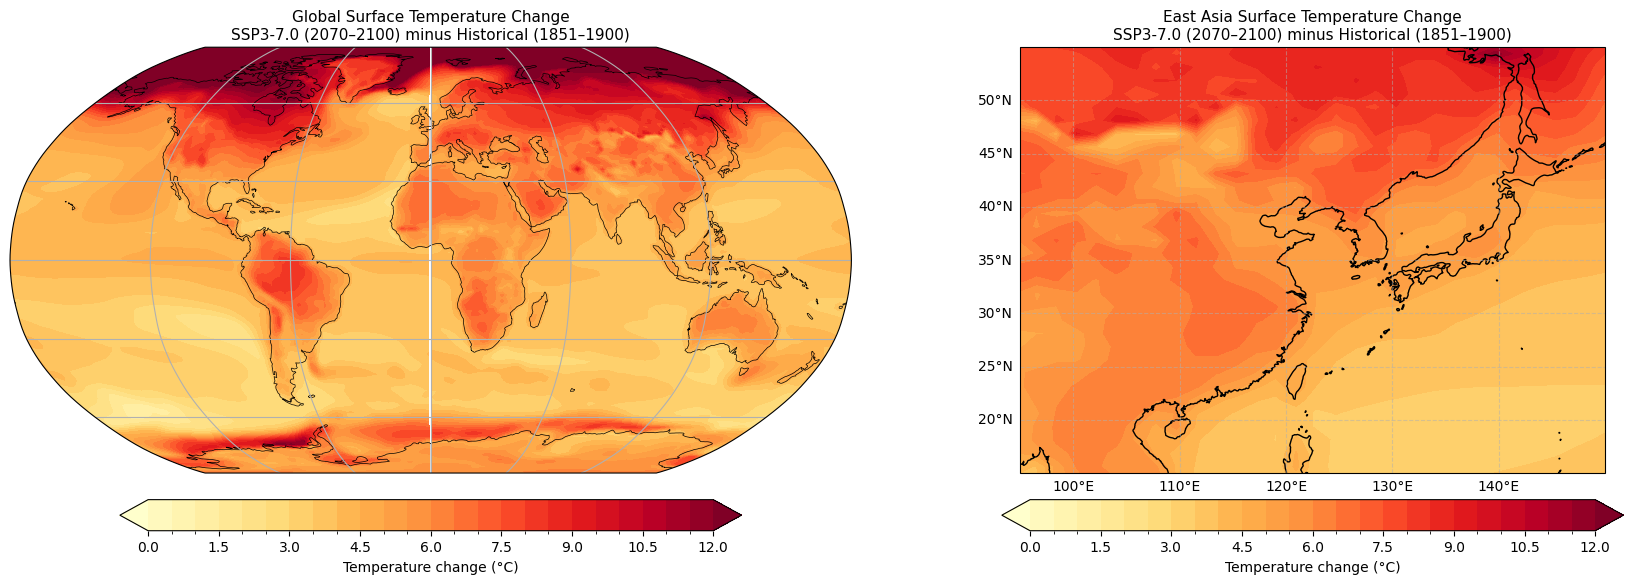

In [ ]:
#Spatial plotting
#differences
tas_future   = tas_370.sel(time=tas_370.time.dt.year.isin(range(2070, 2101))).mean('time')
tas_baseline = tas_hist.sel(time=tas_hist.time.dt.year.isin(range(1851, 1901))).mean('time')
diff = (tas_future - tas_baseline).compute()

cmap   = 'YlOrRd'
levels = np.linspace(0, 12, 25)


fig = plt.figure(figsize=(18, 6))

# Global
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())
ax1.coastlines(resolution='110m', linewidth=0.5)
ax1.gridlines()
ax1.add_feature(cartopy.feature.LAND, zorder=1,
                facecolor=cartopy.feature.COLORS['land_alt1'])

cf1 = diff.plot.contourf(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    levels=levels,
    cmap=cmap,
    add_colorbar=False,
    extend='both')

ax1.set_title('Global Surface Temperature Change\n'
              'SSP3-7.0 (2070–2100) minus Historical (1851–1900)', fontsize=11)

plt.colorbar(cf1, ax=ax1, orientation='horizontal',
             pad=0.05, shrink=0.7, extend='both',
             label='Temperature change (°C)')

# East Asia
east_asia_extent = [95, 150, 15, 55]

ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree(central_longitude=0.0))
ax2.coastlines()
ax2.add_feature(cartopy.feature.LAND, zorder=1,
                facecolor=cartopy.feature.COLORS['land_alt1'])

gl = ax2.gridlines(draw_labels=True, alpha=0.5, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xformatter   = LONGITUDE_FORMATTER
gl.yformatter   = LATITUDE_FORMATTER

cf2 = diff.plot.contourf(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    levels=levels,
    cmap=cmap,
    add_colorbar=False,
    extend='both')

ax2.set_extent(east_asia_extent, ccrs.PlateCarree())
ax2.set_title('East Asia Surface Temperature Change\n'
              'SSP3-7.0 (2070–2100) minus Historical (1851–1900)', fontsize=11)

plt.colorbar(cf2, ax=ax2, orientation='horizontal',
             pad=0.05, shrink=0.7, extend='both',
             label='Temperature change (°C)')

plt.tight_layout()
plt.show()

In [ ]:
diff_eas = diff.where(mask == 35)
diff_npac = diff.where(mask == 47)
cos_weights = np.cos(np.deg2rad(diff.lat))

# Area weighted mean over East Asia
eas_warming = float(
    diff_eas.weighted(
        np.cos(np.deg2rad(diff.lat))
    ).mean(dim=['lat', 'lon'])
)

# North Pacific warming
npac_warming = float(
    diff_npac.weighted(cos_weights).mean(
        dim=['lat', 'lon']
    )
)

# Global mean warming
global_warming = float(
    diff.weighted(cos_weights).mean(
        dim=['lat', 'lon']
    )
)

print(f'Global mean warming:               '
      f'{global_warming:.2f}°C')
print(f'East Asia               :          '
      f'{eas_warming:.2f}°C')
print(f'North Pacific Ocean                 '
      f' {npac_warming:.2f}°C')
print(f'Land-sea contrast (EAS minus NPO): '
      f'{eas_warming - npac_warming:.2f}°C')
print(f'tas differences between East Asia and Global:  '
      f'{eas_warming - global_warming:.2f}°C')


Global mean warming:               5.07°C
East Asia               :          5.55°C
North Pacific Ocean                  4.44°C
Land-sea contrast (EAS minus NPO): 1.11°C
tas differences between East Asia and Global:  0.48°C


Figure 2: Seasonal changes of psl and pr

In [ ]:
#load cvdp files
cvdp_hist = xr.open_dataset(
    'data/UKESM1_summary_files/UKESM1_ssp370_1850-1900.cvdp_data.1850-2100.nc')

# Future period (2071–2100)
cvdp_ssp= xr.open_dataset(
    'data/UKESM1_summary_files/UKESM1_ssp370_2071-2100.cvdp_data.1850-2100.nc')

In [ ]:
#Summer differences
psl_diff_jja = (cvdp_ssp['psl_spatialmean_jja']
              - cvdp_hist['psl_spatialmean_jja'])

pr_diff_jja  = (cvdp_ssp['pr_spatialmean_jja']
              - cvdp_hist['pr_spatialmean_jja'])

# Winter (DJF) differences
psl_diff_djf = (cvdp_ssp['psl_spatialmean_djf']
              - cvdp_hist['psl_spatialmean_djf'])

pr_diff_djf  = (cvdp_ssp['pr_spatialmean_djf']
              - cvdp_hist['pr_spatialmean_djf'])

# Annual differences
psl_diff_ann = (cvdp_ssp['psl_spatialmean_ann']
              - cvdp_hist['psl_spatialmean_ann'])

pr_diff_ann  = (cvdp_ssp['pr_spatialmean_ann']
              - cvdp_hist['pr_spatialmean_ann'])


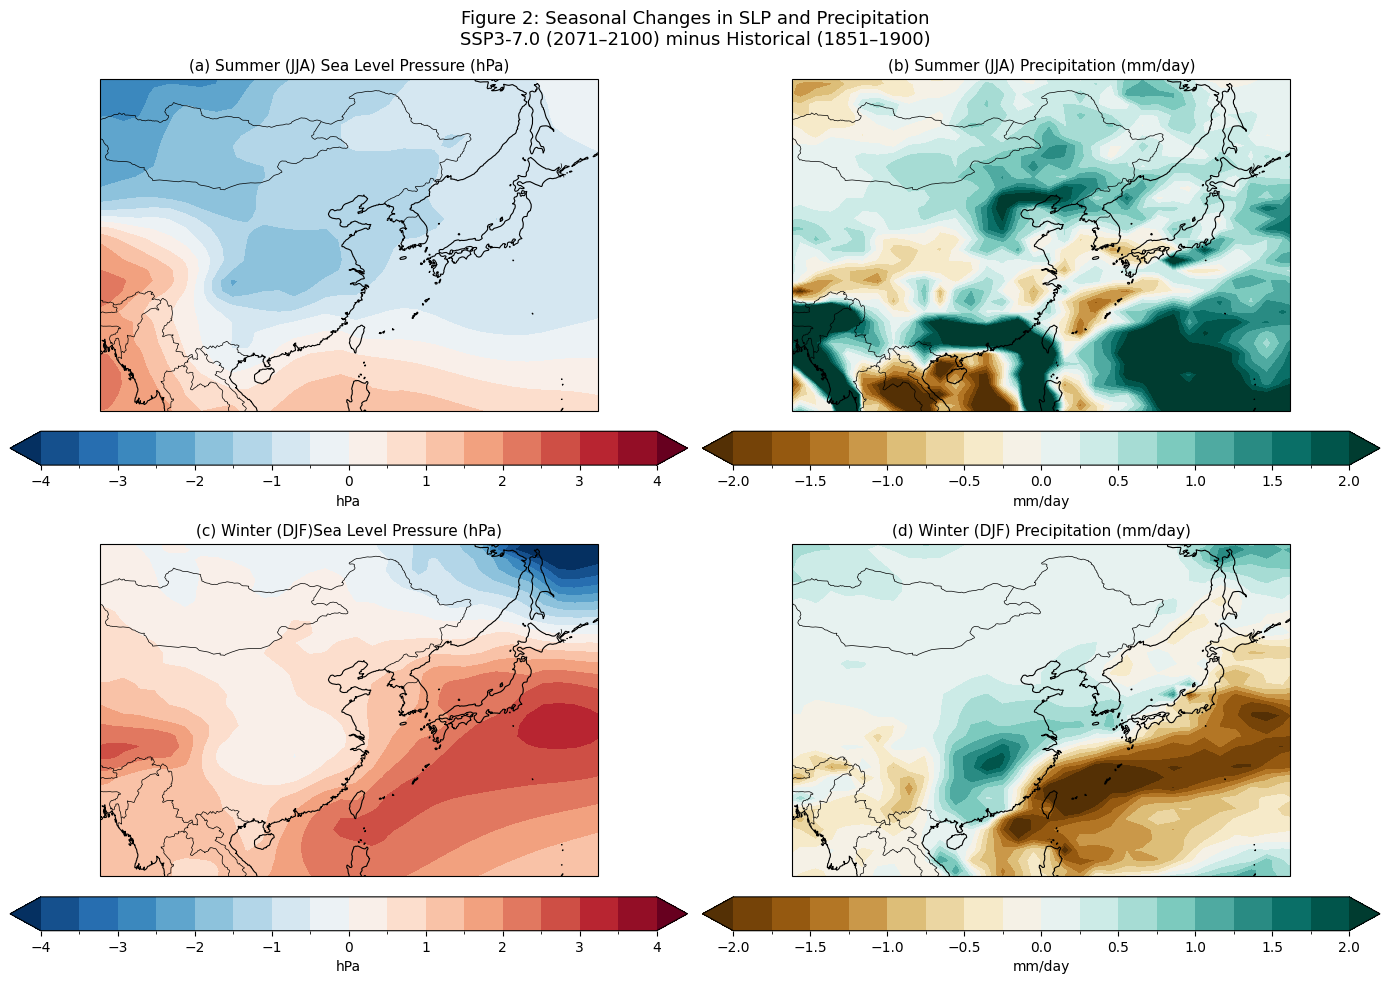

In [ ]:
# East Asia extent
east_asia = [90, 150, 15, 55]

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

fig.suptitle(
    'Figure 2: Seasonal Changes in SLP and '
    'Precipitation\nSSP3-7.0 (2071–2100) minus '
    'Historical (1851–1900)',
    fontsize=13
)

#summer psl
ax = axes[0, 0]
im1 = psl_diff_jja.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    levels=np.linspace(-4, 4, 17),
    add_colorbar=False,
    extend='both'
)
ax.set_extent(east_asia, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title('(a) Summer (JJA) Sea Level Pressure (hPa)',
             fontsize=11)
plt.colorbar(im1, ax=ax, orientation='horizontal',
             pad=0.05, label='hPa')

#summer precipitation
ax = axes[0, 1]
im2 = pr_diff_jja.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=np.linspace(-2, 2, 17),
    add_colorbar=False,
    extend='both'
)
ax.set_extent(east_asia, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title('(b) Summer (JJA) Precipitation (mm/day)',
             fontsize=11)
plt.colorbar(im2, ax=ax, orientation='horizontal',
             pad=0.05, label='mm/day')

#winter psl
ax = axes[1, 0]
im3 = psl_diff_djf.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    levels=np.linspace(-4, 4, 17),
    add_colorbar=False,
    extend='both'
)
ax.set_extent(east_asia, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title('(c) Winter (DJF)Sea Level Pressure (hPa)',
             fontsize=11)
plt.colorbar(im3, ax=ax, orientation='horizontal',
             pad=0.05, label='hPa')

# winter precipitation
ax = axes[1, 1]
im4 = pr_diff_djf.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=np.linspace(-2, 2, 17),
    add_colorbar=False,
    extend='both'
)
ax.set_extent(east_asia, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title('(d) Winter (DJF) Precipitation (mm/day)',
             fontsize=11)
plt.colorbar(im4, ax=ax, orientation='horizontal',
             pad=0.05, label='mm/day')

plt.tight_layout()
plt.show()

In [ ]:
#summary statisitc

# Region
ea_lat = slice(20, 50)
ea_lon = slice(100, 145)

# JJA statistics
psl_jja_ea = psl_diff_jja_plot.sel(
    lat=ea_lat, lon=ea_lon
)
pr_jja_ea = pr_diff_jja_plot.sel(
    lat=ea_lat, lon=ea_lon
)

# DJF statistics
psl_djf_ea = psl_diff_djf_plot.sel(
    lat=ea_lat, lon=ea_lon
)
pr_djf_ea = pr_diff_djf_plot.sel(
    lat=ea_lat, lon=ea_lon
)


print('\nJJA (Summer) over East Asia:')
print(f'  SLP mean change:      '
      f'{float(psl_jja_ea.mean()):.2f} hPa')
print(f'  SLP max decrease:     '
      f'{float(psl_jja_ea.min()):.2f} hPa')
print(f'  SLP max increase:     '
      f'{float(psl_jja_ea.max()):.2f} hPa')
print(f'  PR mean change:       '
      f'{float(pr_jja_ea.mean()):.2f} mm/day')
print(f'  PR max increase:      '
      f'{float(pr_jja_ea.max()):.2f} mm/day')
print(f'  PR max decrease:      '
      f'{float(pr_jja_ea.min()):.2f} mm/day')

# Calculate percentage change
pr_jja_hist = cvdp_hist['pr_spatialmean_jja'].sel(
    lat=ea_lat, lon=ea_lon
)
if 'kg' in pr_units.lower():
    pr_jja_hist = pr_jja_hist * 86400
pr_jja_pct = (float(pr_jja_ea.mean()) /
              float(pr_jja_hist.mean())) * 100
print(f'  PR mean % change:     '
      f'{pr_jja_pct:.1f}%')

print('\nDJF (Winter) over East Asia:')
print(f'  SLP mean change:      '
      f'{float(psl_djf_ea.mean()):.2f} hPa')
print(f'  SLP max decrease:     '
      f'{float(psl_djf_ea.min()):.2f} hPa')
print(f'  SLP max increase:     '
      f'{float(psl_djf_ea.max()):.2f} hPa')
print(f'  PR mean change:       '
      f'{float(pr_djf_ea.mean()):.2f} mm/day')
print(f'  PR max increase:      '
      f'{float(pr_djf_ea.max()):.2f} mm/day')
print(f'  PR max decrease:      '
      f'{float(pr_djf_ea.min()):.2f} mm/day')

pr_djf_hist = cvdp_hist['pr_spatialmean_djf'].sel(
    lat=ea_lat, lon=ea_lon
)
if 'kg' in pr_units.lower():
    pr_djf_hist = pr_djf_hist * 86400
pr_djf_pct = (float(pr_djf_ea.mean()) /
              float(pr_djf_hist.mean())) * 100
print(f'  PR mean % change:     '
      f'{pr_djf_pct:.1f}%')

print('\nSummry')
print(f'  JJA PR change larger than DJF? '
      f'{float(pr_jja_ea.mean()) > float(pr_djf_ea.mean())}')
print(f'  JJA SLP decrease larger than DJF? '
      f'{float(psl_jja_ea.mean()) < float(psl_djf_ea.mean())}')



JJA (Summer) over East Asia:
  SLP mean change:      -0.88 hPa
  SLP max decrease:     -2.11 hPa
  SLP max increase:     0.77 hPa
  PR mean change:       0.62 mm/day
  PR max increase:      11.30 mm/day
  PR max decrease:      -2.90 mm/day
  PR mean % change:     10.8%

DJF (Winter) over East Asia:
  SLP mean change:      1.09 hPa
  SLP max decrease:     -2.11 hPa
  SLP max increase:     3.16 hPa
  PR mean change:       -0.25 mm/day
  PR max increase:      1.97 mm/day
  PR max decrease:      -3.88 mm/day
  PR mean % change:     -11.7%

Summry
  JJA PR change larger than DJF? True
  JJA SLP decrease larger than DJF? True


East Asia PR (historical): 3.675 mm/day
East Asia PR (SSP3-7.0):   3.789 mm/day
East Asia PR change:       0.114 mm/day (3.1%)

East Asia SLP (historical): 1014.94 hPa
East Asia SLP (SSP3-7.0):   1015.00 hPa
East Asia SLP change:       0.05 hPa

PR increases? True
SLP decreases? False

Data ranges for colour scales:
PR hist: 0.01 to 22.93 mm/day
PR ssp:  0.03 to 27.21 mm/day
PR diff: -5.15 to 6.60 mm/day
PSL hist: 984.8 to 1025.1 hPa
PSL ssp:  980.9 to 1024.7 hPa
PSL diff: -6.56 to 4.41 hPa


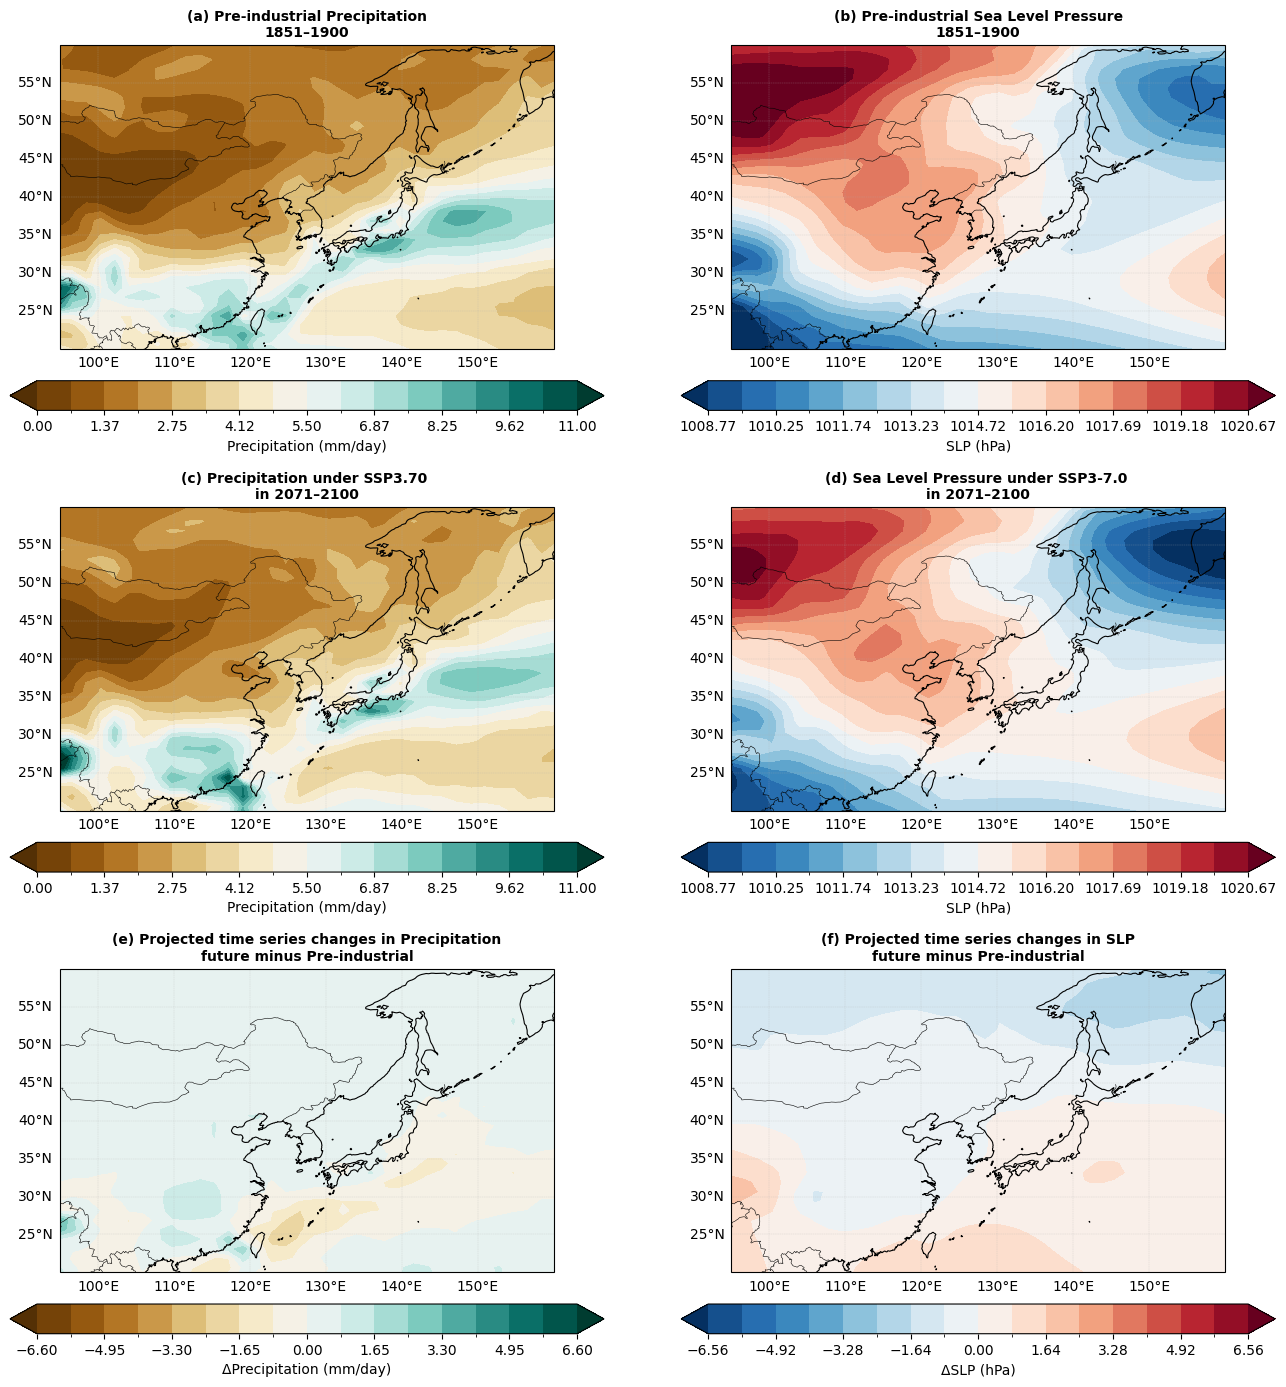

In [ ]:
# Precipitation spatial means
pr_hist = cvdp_hist['pr_spatialmean_ann']
pr_ssp  = cvdp_ssp['pr_spatialmean_ann']

# SLP spatial means
psl_hist = cvdp_hist['psl_spatialmean_ann']
psl_ssp  = cvdp_ssp['psl_spatialmean_ann']


pr_diff  = pr_ssp  - pr_hist
psl_diff = psl_ssp - psl_hist


# East Asia region
ea = dict(lat=slice(20, 50),
          lon=slice(100, 145))

# PR
pr_hist_ea = float(pr_hist.sel(**ea).mean())
pr_ssp_ea  = float(pr_ssp.sel(**ea).mean())
pr_diff_ea = float(pr_diff.sel(**ea).mean())
pr_pct     = (pr_diff_ea / pr_hist_ea) * 100

# PSL
psl_hist_ea = float(psl_hist.sel(**ea).mean())
psl_ssp_ea  = float(psl_ssp.sel(**ea).mean())
psl_diff_ea = float(psl_diff.sel(**ea).mean())


print(f'East Asia PR (historical): '
      f'{pr_hist_ea:.3f} {pr_unit}')
print(f'East Asia PR (SSP3-7.0):   '
      f'{pr_ssp_ea:.3f} {pr_unit}')
print(f'East Asia PR change:       '
      f'{pr_diff_ea:.3f} {pr_unit} '
      f'({pr_pct:.1f}%)')
print(f'\nEast Asia SLP (historical): '
      f'{psl_hist_ea:.2f} {psl_unit}')
print(f'East Asia SLP (SSP3-7.0):   '
      f'{psl_ssp_ea:.2f} {psl_unit}')
print(f'East Asia SLP change:       '
      f'{psl_diff_ea:.2f} {psl_unit}')
print(f'\nPR increases? {pr_diff_ea > 0}')
print(f'SLP decreases? {psl_diff_ea < 0}')

#colour scale bar
print('\nData ranges for colour scales:')
print(f'PR hist: {float(pr_hist.min()):.2f} '
      f'to {float(pr_hist.max()):.2f} {pr_unit}')
print(f'PR ssp:  {float(pr_ssp.min()):.2f} '
      f'to {float(pr_ssp.max()):.2f} {pr_unit}')
print(f'PR diff: {float(pr_diff.min()):.2f} '
      f'to {float(pr_diff.max()):.2f} {pr_unit}')
print(f'PSL hist: {float(psl_hist.min()):.1f} '
      f'to {float(psl_hist.max()):.1f} {psl_unit}')
print(f'PSL ssp:  {float(psl_ssp.min()):.1f} '
      f'to {float(psl_ssp.max()):.1f} {psl_unit}')
print(f'PSL diff: {float(psl_diff.min()):.2f} '
      f'to {float(psl_diff.max()):.2f} {psl_unit}')
#Plot
east_asia = [95, 160, 20, 60]

fig, axes = plt.subplots(
    3, 2,
    figsize=(14, 14),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

def plot_map(ax, data, cmap, levels,
             title, cbar_label,
             extent=east_asia):
    """Plot one spatial panel"""
    im = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        levels=levels,
        add_colorbar=False,
        extend='both'
    )
    ax.set_extent(extent,
                  crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE,
                   linewidth=0.8)
    ax.add_feature(cfeature.BORDERS,
                   linewidth=0.4)
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        alpha=0.5,
        linestyle='--'
    )
    gl.top_labels   = False
    gl.right_labels = False
    ax.set_title(title, fontsize=10,
                 fontweight='bold')
    plt.colorbar(
        im, ax=ax,
        orientation='horizontal',
        pad=0.08,
        label=cbar_label,
        shrink=0.85
    )
    return im

#colour scale bar

# PR absolute levels
pr_abs_max = max(
    float(pr_hist.sel(**ea).max()),
    float(pr_ssp.sel(**ea).max())
)
pr_abs_levels = np.linspace(0, pr_abs_max, 17)

# PR difference levels
pr_diff_abs = max(
    abs(float(pr_diff.min())),
    abs(float(pr_diff.max()))
)
pr_diff_levels = np.linspace(
    -pr_diff_abs, pr_diff_abs, 17
)

# PSL absolute levels
psl_abs_min = min(
    float(psl_hist.sel(**ea).min()),
    float(psl_ssp.sel(**ea).min())
)
psl_abs_max = max(
    float(psl_hist.sel(**ea).max()),
    float(psl_ssp.sel(**ea).max())
)
psl_abs_levels = np.linspace(
    psl_abs_min, psl_abs_max, 17
)

# PSL difference levels
psl_diff_abs = max(
    abs(float(psl_diff.min())),
    abs(float(psl_diff.max()))
)
psl_diff_levels = np.linspace(
    -psl_diff_abs, psl_diff_abs, 17
)

#6 time series panel plotting
# (a)  Pre-industrial Precipitation
plot_map(
    ax=axes[0, 0],
    data=pr_hist,
    cmap='BrBG',
    levels=pr_abs_levels,
    title='(a) Pre-industrial Precipitation\n'
          '1851–1900',
    cbar_label=f'Precipitation ({pr_unit})'
)

#  (b)  Pre-industrial SLP
plot_map(
    ax=axes[0, 1],
    data=psl_hist,
    cmap='RdBu_r',
    levels=psl_abs_levels,
    title='(b) Pre-industrial Sea Level Pressure\n'
          '1851–1900',
    cbar_label=f'SLP ({psl_unit})'
)

#SSP370

#  (c)  Precipitation
plot_map(
    ax=axes[1, 0],
    data=pr_ssp,
    cmap='BrBG',
    levels=pr_abs_levels,
    title='(c) Precipitation under SSP3.70 \n'
          'in 2071–2100',
    cbar_label=f'Precipitation ({pr_unit})'
)

# (d)SLP
plot_map(
    ax=axes[1, 1],
    data=psl_ssp,
    cmap='RdBu_r',
    levels=psl_abs_levels,
    title='(d) Sea Level Pressure under SSP3-7.0 \n'
          'in 2071–2100',
    cbar_label=f'SLP ({psl_unit})'
)

#Time series changes of SLP and Precipitation (Future-Historial)

# Panel (e) Precipitation
plot_map(
    ax=axes[2, 0],
    data=pr_diff,
    cmap='BrBG',
    levels=pr_diff_levels,
    title='(e) Projected time series changes in Precipitation\n'
          'future minus Pre-industrial',
    cbar_label=f'ΔPrecipitation ({pr_unit})'
)

# Panel (f)  SLP Difference
plot_map(
    ax=axes[2, 1],
    data=psl_diff,
    cmap='RdBu_r',
    levels=psl_diff_levels,
    title='(f) Projected time series changes in SLP\n'
          'future minus Pre-industrial',
    cbar_label=f'ΔSLP ({psl_unit})'
)

plt.tight_layout()
plt.show()

In [ ]:
#latitude height plot
#load atmospheric temperature file
ta_hist= xr.open_mfdataset(
    ['Data/ta_Amon_UKESM1-0-LL_historical_r1i1p1f2_gn_185001-194912.nc',
     'data/UKESM1_model_output/historical/ta_Amon_UKESM1-0-LL_historical_r1i1p1f2_gn_195001-201412.nc'],
    combine='by_coords')['ta']
ta_370= xr.open_dataset(
    'Data/ta_Amon_UKESM1-0-LL_ssp370_r1i1p1f2_gn_205001-210012.nc')['ta']

New shape (plev x lat): (19, 20)
Latitude range: 15.625 to 39.375
Upper troposphere (200-300 hPa): 6.99°C
Near-surface (850-1000 hPa):     4.65°C
Level of maximum warming:        250 hPa
Maximum warming value:           7.16°C
Upper > surface warming?         True


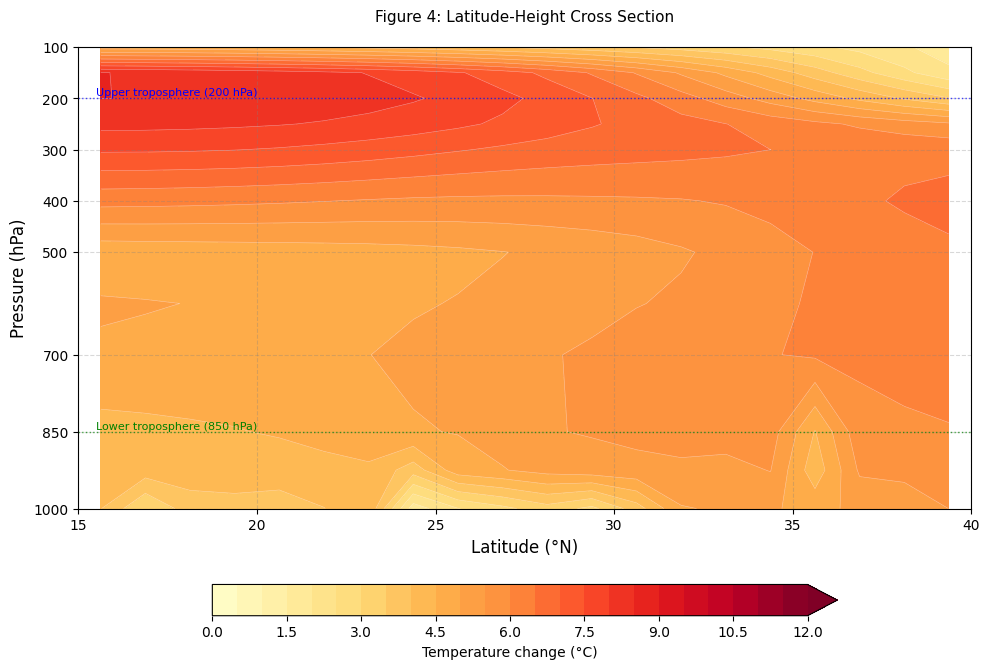

In [ ]:
#latitude in zonal average

ta_baseline_zonal = ta_baseline.sel(
    lat=slice(15, 40),
    lon=slice(100, 145)
).mean(dim='lon')

ta_future_zonal = ta_future.sel(
    lat=slice(15, 40),
    lon=slice(100, 145)
).mean(dim='lon')

ta_diff_zonal = ta_future_zonal - ta_baseline_zonal
#sanity check for the shape
print('New shape (plev x lat):',
      ta_diff_zonal.shape)
print('Latitude range:',
      float(ta_diff_zonal.lat.min()),
      'to',
      float(ta_diff_zonal.lat.max()))


plev_hpa = ta_diff_zonal.plev.values / 100

upper_trop = float(
    ta_diff_zonal.sel(
        plev=slice(30000, 20000)
    ).mean()
)
near_surface = float(
    ta_diff_zonal.sel(
        plev=slice(100000, 85000)
    ).mean()
)
max_level_idx = ta_diff_zonal.mean(
    dim='lat'
).values.argmax()
max_level_hpa = plev_hpa[max_level_idx]
max_warming   = float(
    ta_diff_zonal.mean(dim='lat').max()
)


print(f'Upper troposphere (200-300 hPa): '
      f'{upper_trop:.2f}°C')
print(f'Near-surface (850-1000 hPa):     '
      f'{near_surface:.2f}°C')
print(f'Level of maximum warming:        '
      f'{max_level_hpa:.0f} hPa')
print(f'Maximum warming value:           '
      f'{max_warming:.2f}°C')
print(f'Upper > surface warming?         '
      f'{upper_trop > near_surface}')

#Plotting

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

plev_hpa = ta_diff_zonal.plev.values / 100
lats     = ta_diff_zonal.lat.values
levels_diff = np.linspace(0, 12, 25)

cf = ax.contourf(
    lats,
    plev_hpa,
    ta_diff_zonal.values,
    levels=levels_diff,
    cmap='Plasma',
    extend='max'
)

ax.contour(
    lats,
    plev_hpa,
    ta_diff_zonal.values,
    levels=levels_diff,
    colors='white',
    linewidths=0.4,
    alpha=0.5
)

cbar = fig.colorbar(
    cf, ax=ax,
    orientation='horizontal',
    pad=0.12, shrink=0.7,
    label='Temperature change (°C)'
)

ax.invert_yaxis()
ax.set_yticks([1000, 850, 700, 500,
               400, 300, 200, 100])
ax.set_yticklabels(['1000', '850', '700',
                    '500', '400', '300',
                    '200', '100'])

ax.set_xlim(15, 40)
ax.set_xticks([15, 20, 25, 30, 35, 40])

ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_xlabel('Latitude (°N)', fontsize=12)


ax.set_title(
    'Figure 4: Latitude-Height Cross Section\n',
    fontsize=11
)

ax.grid(True, alpha=0.3,
        linestyle='--', color='grey')

# Annotation
ax.axhline(200, color='blue',
           lw=1, ls=':', alpha=0.7)
ax.text(15.5, 195,
        'Upper troposphere (200 hPa)',
        fontsize=8, color='blue')
ax.axhline(850, color='green',
           lw=1, ls=':', alpha=0.7)
ax.text(15.5, 845,
        'Lower troposphere (850 hPa)',
        fontsize=8, color='green')

plt.tight_layout()
plt.show()